# Tarea Semanal 6: Primeras nociones de estimación espectral: Ancho de banda de señales.
**Autor:** Marco Trabattoni  
**Cátedra:** Procesamiento Digital de Señales - R6051  
**Docente:** Mariano Llamedo Soria
 
---

## 1. Introducción

En el repositorio [PDStestbench](https://github.com/tu-usuario/PDStestbench) encontrará tres tipos de señales registradas:

* **Electrocardiograma (ECG)**. En el archivo **ECG_TP4.mat** encontrará un registro electrocardiográfico (ECG) registrado durante una prueba de esfuerzo, junto con una serie de variables descriptas más abajo.
* **Pletismografía (PPG)**. El archivo **PPG.csv** contiene una señal registrada en reposo de un estudiante de la materia que ha donado su registro para esta actividad.
* **Audio**. Tres registros en los que el profesor pronuncia una frase, y otros dos en los que se silba una melodía muy conocida.

Los detalles de cómo acceder a dichos registros los pueden encontrar en [lectura_sigs.py](https://github.com/marianux/pdstestbench/blob/master/lectura_sigs.py).

Se realizará:

**1)** Estimación de la densidad espectral de potencia (PSD) de cada señal mediante alguno de los métodos vistos en clase (Periodograma ventaneado, Welch, Blackman-Tukey).

**2)** Estimación del ancho de banda de cada señal y presente los resultados en un tabla para facilitar la comparación.

Bonus:

* 💎 Proponemos una señal multitono para repetir el análisis.

## 2. Configuración
En esta sección se importan las librerías necesarias (`numPy`, `scipy.signal`, `scipy.io` y `matplotlib.pyplot`), definimos los algoritmos de trabajo y realizamos la lectura de los archivos de **Electrocardiograma (ECG)**, **Pletismografía (PPG)** y **Audio** propuestos.

In [16]:
import numpy as np
import scipy.signal as sig
import scipy.io as sio
import matplotlib.pyplot as plt

#%%
def calcular_ancho_banda(frecuencias, psd, porcentaje):
    """ Determina la frecuencia donde se acumula el porcentaje de potencia dado """
    potencia_total = np.sum(psd)
    potencia_acumulada = np.cumsum(psd)
    idx_bw = np.where(potencia_acumulada >= potencia_total * porcentaje)[0][0]
    return frecuencias[idx_bw]


#%% Lectura de archivos
fs_ecg = 1000  
ecg_sig = sio.loadmat('./ECG_TP4.mat')['ecg_lead'].ravel()

fs_ppg = 400   
ppg_sig = np.genfromtxt('PPG.csv', delimiter=',', skip_header=1)

fs_audio, audio_data = sio.wavfile.read('silbido.wav')


## 3. Fundamentación teórica y análisis

En el Procesamiento Digital de Señales, la selección de un estimador espectral no paramétrico está regida por el balance entre **sesgo** (resolución en frecuencia) y **varianza** (ruido del estimador). 

A continuación se detalla el criterio de selección del método óptimo según la naturaleza física de cada registro:

### Electrocardiograma (ECG) — Archivo `ECG_TP4.mat`
El método utilizado será el "Método de Welch" (Periodograma promediado).

Al tratarse de un registro electrocardiográfico tomado durante una prueba de esfuerzo, la señal se encuentra fuertemente contaminada por artefactos de movimiento, variaciones en la impedancia de los electrodos por respiración (ruido de línea de base) y ruido muscular de alta frecuencia. 

El uso de un periodograma simple generaría una estimación con una varianza increiblemente alta. 

El método de Welch mitiga este efecto al segmentar la señal, aplicar una ventana suavizada y promediar los resultados, reduciendo la varianza a costa de una pérdida menor en la resolución espectral fina.

La energía útil del complejo cardíaco se confina en bajas frecuencias, típicamente entre $0.5\text{ Hz}$ y $40\text{ Hz}$. Debido a las condiciones de esfuerzo, se espera una alta concentración de potencia espectral en la vecindad de $0\text{ Hz}$ producto del desplazamiento dinámico de la línea de base.

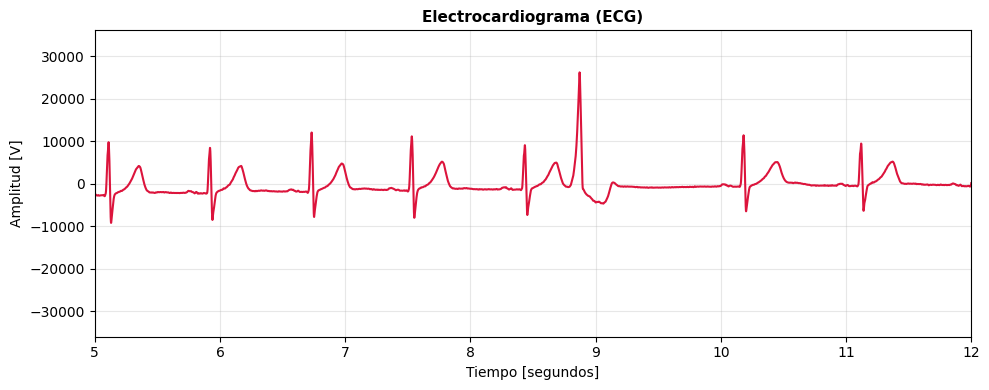

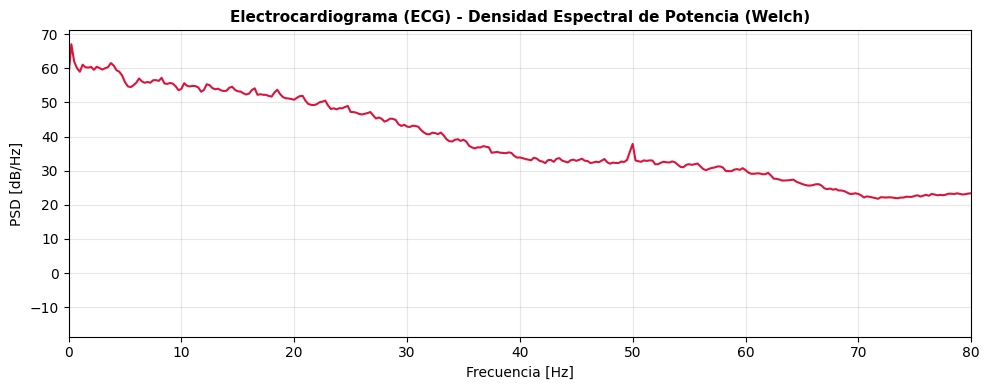

In [17]:
#%% ECG en el Tiempo
t_ecg = np.arange(len(ecg_sig)) / fs_ecg

plt.figure(figsize=(10, 4))
plt.plot(t_ecg, ecg_sig, color='crimson')
plt.title('Electrocardiograma (ECG)', fontsize=11, fontweight='bold')
plt.xlim(5, 12)
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#%% ECG en Frecuencia (PSD)

# ECG: Método de Welch
f_ecg, psd_ecg = sig.welch(ecg_sig, fs=fs_ecg, window='hamming', nperseg=4000)

plt.figure(figsize=(10, 4))
plt.plot(f_ecg, 10 * np.log10(psd_ecg + 1e-12), color='crimson')
plt.title('Electrocardiograma (ECG) - Densidad Espectral de Potencia (Welch)', fontsize=11, fontweight='bold')
plt.xlim(0, 80)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### B. Pletismografía (PPG) — Archivo `PPG.csv`

El método sugerido será Método de Welch. 

Al igual que el ECG, el pulso pletismográfico óptico periférico es una señal quasi-periódica de origen biológico. Si bien el registro fue tomado en condiciones de reposo, los sensores ópticos suelen incorporar ruido estocástico de alta frecuencia derivado del ruido térmico del fotodetector e interferencias lumínicas ambientales. 

El suavizado por promediado del método de Welch remueve estas componentes parásitas de alta frecuencia, facilitando la identificación nítida de la frecuencia fundamental y sus armónicos.

Al ser una señal sumamente lenta, cuya energía útil se concentra en una banda muy estrecha por debajo de los $10\text{ Hz}$. El pico espectral de mayor magnitud identifica de forma directa la frecuencia cardíaca instantánea del sujeto bajo análisis.


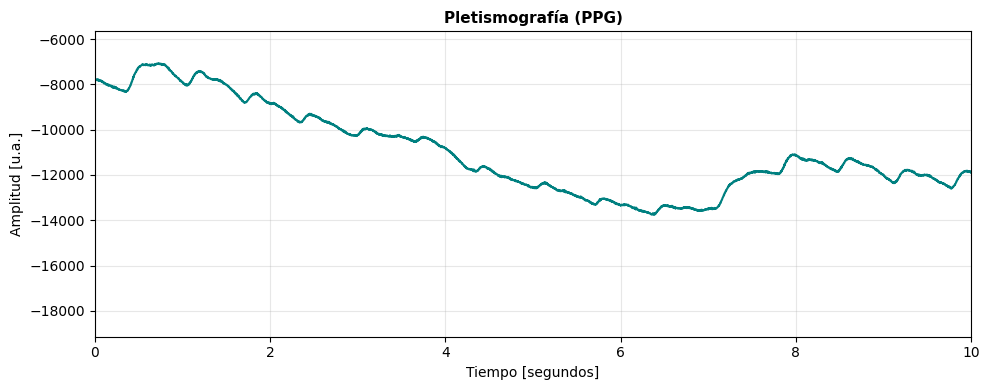

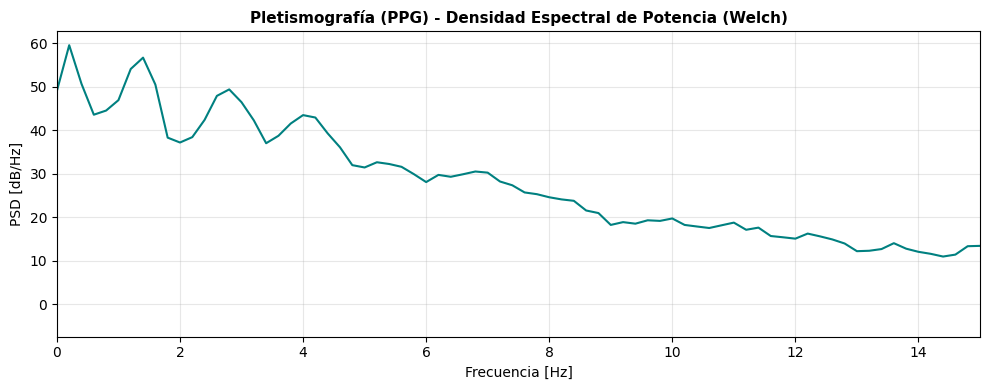

In [18]:
#%% PPG en el Tiempo
t_ppg = np.arange(len(ppg_sig)) / fs_ppg

plt.figure(figsize=(10, 4))
plt.plot(t_ppg, ppg_sig, color='teal')
plt.title('Pletismografía (PPG)', fontsize=11, fontweight='bold')
plt.xlim(0, 10)
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [u.a.]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#%% PPG en Frecuencia (PSD)

# PPG: Método de Welch
f_ppg, psd_ppg = sig.welch(ppg_sig, fs=fs_ppg, window='hamming', nperseg=2000)


plt.figure(figsize=(10, 4))
plt.plot(f_ppg, 10 * np.log10(psd_ppg + 1e-12), color='teal')
plt.title('Pletismografía (PPG) - Densidad Espectral de Potencia (Welch)', fontsize=11, fontweight='bold')
plt.xlim(0, 15)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### C. Audio (Voz y Silbido) — Archivos `.wav`

El método sugerido será el Periodograma Ventaneado (Ventana de Hamming).

Las señales acústicas son no estacionarias y se caracterizan por variaciones rápidas en sus componentes de frecuencia o por poseer armónicos puros muy próximos entre sí. 
El método de Welch degradaría la resolución local debido al truncamiento en bloques cortos. Se requiere un enfoque de bajo sesgo. Por lo tanto, se procesa el registro completo mediante un Periodograma Ventaneado. 

Multiplicar la secuencia por una ventana de Hamming reduce el fenómeno de spectral leakage, impidiendo que los lóbulos laterales de componentes de gran amplitud enmascaren frecuencias débiles adyacentes.

El silbido presenta un comportamiento cercano a un tono puro, manifestándose como picos espectrales agudos y de alta energía concentrados en la banda de frecuencias medias (entre $1000\text{ Hz}$ y $3000\text{ Hz}$). Mientras que voz exhibe una distribución de energía más compleja, caracterizada por la presencia de picos anchos, distribuidos en el espectro audible entre los $100\text{ Hz}$ y $4000\text{ Hz}$.

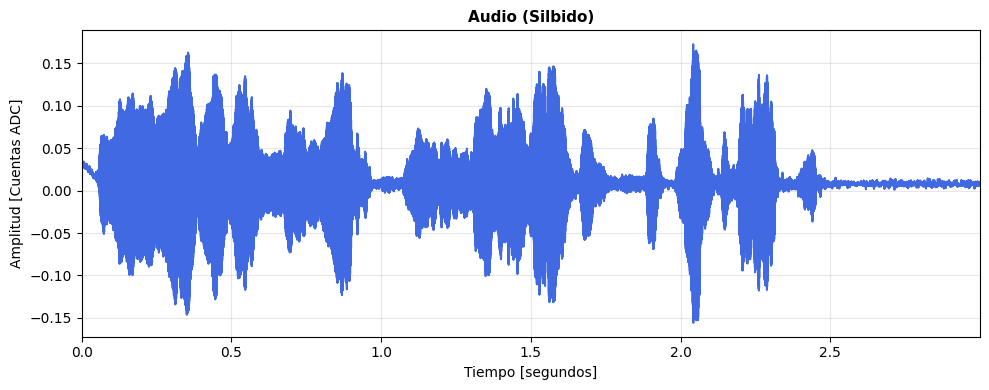

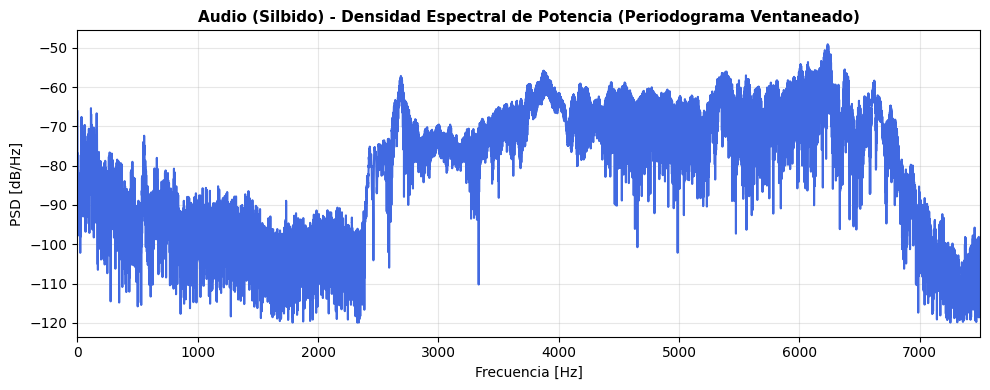

In [19]:
#%% Audio en el Tiempo
t_audio = np.arange(len(audio_data)) / fs_audio

plt.figure(figsize=(10, 4))
plt.plot(t_audio, audio_data, color='royalblue')
plt.title('Audio (Silbido)', fontsize=11, fontweight='bold')
plt.xlim(0, t_audio[-1])
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud [Cuentas ADC]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#%% Audio en Frecuencia (PSD)

# Audio: Periodograma Ventaneado 
w_audio = sig.windows.hamming(len(audio_data))
f_audio, psd_audio = sig.periodogram(audio_data, fs=fs_audio, window=w_audio)

plt.figure(figsize=(10, 4))
plt.plot(f_audio, 10 * np.log10(psd_audio + 1e-12), color='royalblue')
plt.title('Audio (Silbido) - Densidad Espectral de Potencia (Periodograma Ventaneado)', fontsize=11, fontweight='bold')
plt.xlim(0, 7500)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Estimación de Ancho de Banda

Dado que las señales del mundo real poseen transiciones espectrales suaves y carecen de un corte abrupto de ganancia, se adopta el criterio estadístico de **Ancho de Banda por Potencia Contenida**. Matemáticamente, se utiliza la integral discreta de la PSD mediante la función de distribución acumulada:

$$\text{Potencia Acumulada}(f) = \sum_{i=0}^{f} \text{PSD}(i)$$

Se definen dos umbrales diferenciados según la aplicación:
1. **Señales Biomédicas (ECG y PPG):** Se computa el ancho de banda al **99% de la potencia total**. Esto garantiza abarcar de forma estricta la morfología de la onda útil, aislando únicamente el ruido de alta frecuencia residual.
2. **Señales Acústicas (Audio):** Se establece el umbral al **95% de la potencia total** para evitar que ruidos de fondo de carácter estocástico o de banda ancha inflen de forma artificial la estimación del ancho de banda útil.

In [20]:
#%% ESTIMACIÓN DEL ANCHO DE BANDA

bw_ecg = calcular_ancho_banda(f_ecg, psd_ecg, porcentaje=0.99) # 99% Energía
bw_ppg = calcular_ancho_banda(f_ppg, psd_ppg, porcentaje=0.99) # 99% Energía
bw_audio = calcular_ancho_banda(f_audio, psd_audio, porcentaje=0.95) # 95% Energía

print("\n" + "="*92)
print(f"{'TABLA COMPARATIVA DE ANCHO DE BANDA':^85}")
print("="*92)
print(f"{'Tipo de Señal':<20} | {'Fs (Hz)':<10} | {'Método PSD':<25} | {'Criterio':<10} | {'BW Estimado':<15}")
print("-"*92)
print(f"{'ECG (Esfuerzo)':<20} | {fs_ecg:<10.1f} | {'Welch (Hamming)':<25} | {'99% Pot.':<10} | {bw_ecg:>11.2f} Hz")
print(f"{'PPG (Reposo)':<20} | {fs_ppg:<10.1f} | {'Welch (Hamming)':<25} | {'99% Pot.':<10} | {bw_ppg:>11.2f} Hz")
print(f"{'Audio (Silbido)':<20} | {fs_audio:<10.1f} | {'Periodograma (Hamm)':<25} | {'95% Pot.':<10} | {bw_audio:>11.2f} Hz")
print("="*92)



                         TABLA COMPARATIVA DE ANCHO DE BANDA                         
Tipo de Señal        | Fs (Hz)    | Método PSD                | Criterio   | BW Estimado    
--------------------------------------------------------------------------------------------
ECG (Esfuerzo)       | 1000.0     | Welch (Hamming)           | 99% Pot.   |       31.00 Hz
PPG (Reposo)         | 400.0      | Welch (Hamming)           | 99% Pot.   |        4.60 Hz
Audio (Silbido)      | 48000.0    | Periodograma (Hamm)       | 95% Pot.   |     6408.33 Hz


## 4. Señal Propuesta para bonus de análisis

Se modela y digitaliza una señal multitono.

* **Origen de la señal:** Se define matemáticamente a partir de la superposición de dos componentes determinísticas sinusoidales puras muy próximas en frecuencia y un proceso estocástico aditivo:
  
  $$x(t) = \sin(2\pi f_1 t) + \sin(2\pi f_2 t) + n(t)$$
  
  Donde las frecuencias se fijan en $f_1 = 100\text{ Hz}$ y $f_2 = 101.5\text{ Hz}$. El término $n(t)$ representa Ruido Blanco Gaussiano (WGN) dimensionado para fijar una relación señal-ruido de $\text{SNR} = 15\text{ dB}$.
  
* **Digitalización:** Se simula un proceso de muestreo ideal continuo a una frecuencia de muestreo $f_s = 1000\text{ Hz}$ tomando una longitud de registro de $N = 1000$ muestras, lo que fija una resolución espectral nativa de:
  
  $$\Delta f = \frac{f_s}{N} = 1\text{ Hz}$$

* **Objetivo:** Dado que la separación entre tonos ($\Delta f_{\text{real}} = 1.5\text{ Hz}$) es inferior al ancho del lóbulo principal de la ventana de Hamming ($4 \cdot \Delta f = 4\text{ Hz}$), el experimento permite verificar cómo la ventana suavizada disminuye el spectral leackage en el piso de ruido, pero a costa de superponer ambos picos en una única componente, evidenciando los límites prácticos de la resolución espectral no paramétrica.


                         TABLA COMPARATIVA DE ANCHO DE BANDA                         
Tipo de Señal        | Fs (Hz)    | Método PSD                | Criterio   | BW Estimado    
--------------------------------------------------------------------------------------------
Multitono (Bonus)    | 1000.0     | Periodograma (Hamm)       | 95% Pot.   |      102.00 Hz


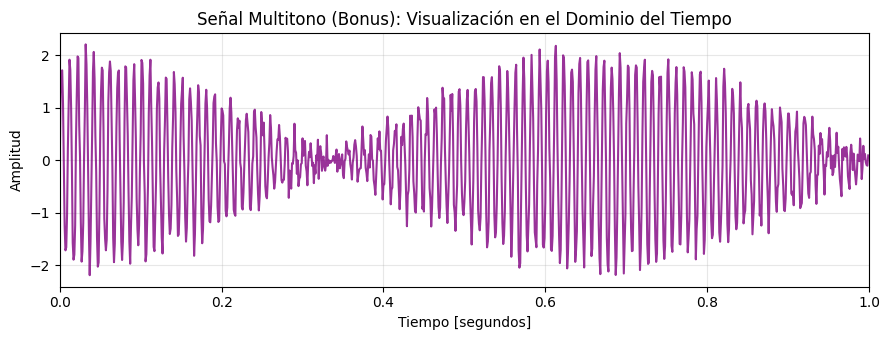

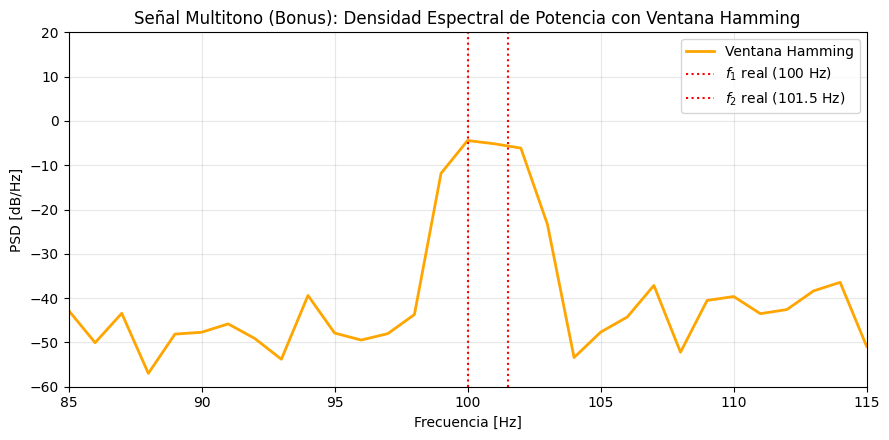

In [21]:
# %% BONUS

# Generación de señal multitono
fs_sin = 1000
N_sin = 1000        
t_sin = np.arange(N_sin) / fs_sin
f1 = 100
f2 = 101.5
SNR = 15

# Ruido Blanco Gaussiano, SNR = 15 dB
ruido = np.random.normal(0, np.sqrt(1.0 / (10**(SNR / 10))), N_sin)
x_sintetica = np.sin(2 * np.pi * f1 * t_sin) + np.sin(2 * np.pi * f2 * t_sin) + ruido

# Estimación espectral con ventana Hamming para calcular su PSD
f_ham, psd_ham = sig.periodogram(x_sintetica, fs=fs_sin, window='hamming')

# Estimación del BW
bw_sin = calcular_ancho_banda(f_ham, psd_ham, porcentaje=0.95)
print("\n" + "="*92)
print(f"{'TABLA COMPARATIVA DE ANCHO DE BANDA':^85}")
print("="*92)
print(f"{'Tipo de Señal':<20} | {'Fs (Hz)':<10} | {'Método PSD':<25} | {'Criterio':<10} | {'BW Estimado':<15}")
print("-"*92)
print(f"{'Multitono (Bonus)':<20} | {fs_sin:<10.1f} | {'Periodograma (Hamm)':<25} | {'95% Pot.':<10} | {bw_sin:>11.2f} Hz")
print("="*92)

# Gráfico en el Dominio del Tiempo
plt.figure(figsize=(9, 3.5))
plt.plot(t_sin, x_sintetica, color='purple', alpha=0.8)
plt.title('Señal Multitono (Bonus): Visualización en el Dominio del Tiempo')
plt.xlabel('Tiempo [segundos]')
plt.ylabel('Amplitud')
plt.xlim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Gráfico de la PSD
plt.figure(figsize=(9, 4.5))
plt.plot(f_ham, 10 * np.log10(psd_ham + 1e-12), label='Ventana Hamming', color='orange', lw=2)
plt.axvline(f1, color='r', ls=':', label=f'$f_1$ real ({f1} Hz)')
plt.axvline(f2, color='r', ls=':', label=f'$f_2$ real ({f2} Hz)')

plt.title('Señal Multitono (Bonus): Densidad Espectral de Potencia con Ventana Hamming')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [dB/Hz]')
plt.xlim(85, 115)
plt.ylim(-60, 20)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Conclusiones Generales

**Validación del Criterio de Selección de Estimadores:** Se corroboró que no existe un único método no paramétrico óptimo global, sino que su elección va de la mano con la naturaleza de la señal y el balance entre sesgo y varianza.

Para señales de origen biológico altamente contaminadas por procesos estocásticos aditivos o artefactos de movimiento (ECG y PPG), el Método de Welch demostró ser el más adecuado. Al promediar los espectros de segmentos solapados, se redujo la varianza del estimador, obteniendo curvas suavizadas que permiten identificar la tendencia de la distribución de potencia sin distorsión.

Para señales de dinámica rápida y componentes armónicas densas (Audio), el Periodograma Ventaneado preservó la resolución espectral necesaria (bajo sesgo), evitando la pérdida de detalles finos que hubiese provocado el promediado de Welch.

**Impacto Físico del Ventaneo y Consecuencias del Goteo Espectral:** La aplicación de la ventana de Hamming demostró ser una herramienta crítica para el control del spectral leakage. Al suavizar las discontinuidades en los extremos del intervalo de observación en el tiempo, se atenuaron los lóbulos laterales en el dominio de la frecuencia. Esto permitió aislar los pisos de ruido y rescatar componentes de baja amplitud que, bajo una ventana Rectangular, habrían quedado ocultas.

**Interpretación y Escalas del Ancho de Banda:** La estimación del ancho de banda mediante el criterio de potencia contenida puso de manifiesto el contraste entre los diferentes sistemas bajo estudio. Las señales biomédicas exhiben dinámicas lentas, concentrando el 99% de su potencia en las bajas frecuencias ($4.60\text{ Hz}$ para PPG y $31.00\text{ Hz}$ para ECG), reflejando la naturaleza fisiológica de los fenómenos bajo análisis. 

En contraposición, las señales acústicas de audio involucran la excitación de alta frecuencia, demandando un ancho de banda de varios Hz ($6408.33\text{ Hz}$ para el silbido al 95% de potencia) para preservar la información.

**Límites Teóricos de la Resolución Espectral (Análisis del Bonus):** El experimento controlado con la señal multitono ($f_1 = 100\text{ Hz}$ y $f_2 = 101.5\text{ Hz}$) expuso de forma transparente los límites de resolución impuestos por el ventaneo. 

Con una ventana Rectangular o con una resolución de $\Delta f = 1\text{ Hz}$, es posible identificar la existencia de ambos tonos. Sin embargo, al aplicar la ventana de Hamming, cuyo lóbulo principal se extiende a $4 / N \cdot f_s = 4\text{ Hz}$, la respuesta en frecuencia de ambos tonos se fundió en una única componente. Esto demostró de manera analítica que la reducción de varianza y la mitigación del spectral leakage siempre se pagan con una pérdida en la capacidad de discriminar frecuencias cercanas.